In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta

# # Definir actividades originales y optimizadas
# tasks = [
#     {"Actividad": "Ingeniería", "Inicio": "2025-01-01", "Duración_original": 90, "Duración_optimizada": 60},
#     {"Actividad": "Compras e importación", "Inicio": "2025-02-01", "Duración_original": 150, "Duración_optimizada": 150},
#     {"Actividad": "Obras civiles", "Inicio": "2025-06-01", "Duración_original": 90, "Duración_optimizada": 60},
#     {"Actividad": "Obras eléctricas", "Inicio": "2025-06-15", "Duración_original": 90, "Duración_optimizada": 60},
#     {"Actividad": "Montaje e instalación", "Inicio": "2025-09-01", "Duración_original": 90, "Duración_optimizada": 60},
#     {"Actividad": "Capacitación", "Inicio": "2025-11-15", "Duración_original": 30, "Duración_optimizada": 15},
#     {"Actividad": "Puesta en marcha", "Inicio": "2025-12-01", "Duración_original": 30, "Duración_optimizada": 30},
# ]

# Definir actividades originales y optimizadas
tasks = [
    {"Actividad": "Ingeniería", "Inicio": "2025-08-01", "Duración_original": 90, "Duración_optimizada": 60},
    {"Actividad": "Compras e importación", "Inicio": "2025-11-01", "Duración_original": 150, "Duración_optimizada": 150},
    {"Actividad": "Obras civiles", "Inicio": "2026-03-01", "Duración_original": 90, "Duración_optimizada": 60},
    {"Actividad": "Obras eléctricas", "Inicio": "2026-06-01", "Duración_original": 90, "Duración_optimizada": 60},
    {"Actividad": "Montaje e instalación", "Inicio": "2026-09-01", "Duración_original": 90, "Duración_optimizada": 60},
    {"Actividad": "Capacitación", "Inicio": "2025-12-01", "Duración_original": 30, "Duración_optimizada": 15},
    {"Actividad": "Puesta en marcha", "Inicio": "2027-01-01", "Duración_original": 30, "Duración_optimizada": 30},
]

# Convertir a DataFrame
df = pd.DataFrame(tasks)
df["Inicio"] = pd.to_datetime(df["Inicio"])
df["Fin_original"] = df["Inicio"] + pd.to_timedelta(df["Duración_original"], unit="D")
df["Fin_optimizada"] = df["Inicio"] + pd.to_timedelta(df["Duración_optimizada"], unit="D")

# Crear gráfico Gantt comparativo
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar barras originales
ax.barh(df["Actividad"], (df["Fin_original"] - df["Inicio"]).dt.days, left=df["Inicio"], color="skyblue", label="Cronograma original")

# Dibujar barras optimizadas
ax.barh(df["Actividad"], (df["Fin_optimizada"] - df["Inicio"]).dt.days, left=df["Inicio"], color="lightgreen", alpha=0.7, label="Cronograma optimizado")

# Formato de fechas
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.xticks(rotation=45)

# Títulos y leyenda
ax.set_title("Comparación de Cronograma del Proyecto", fontsize=14, weight="bold")
ax.set_xlabel("Línea de tiempo")
ax.set_ylabel("Actividades")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Definimos algunos riesgos para el proyecto
riesgos = [
    {"Riesgo": "Demora en importación/aduana", "Probabilidad": "Alta", "Impacto": "Alto"},
    {"Riesgo": "Variación del tipo de cambio", "Probabilidad": "Media", "Impacto": "Alto"},
    {"Riesgo": "Parada de planta > 48h", "Probabilidad": "Baja", "Impacto": "Alto"},
    {"Riesgo": "Falla técnica en montaje", "Probabilidad": "Media", "Impacto": "Medio"},
    {"Riesgo": "Resistencia del personal", "Probabilidad": "Alta", "Impacto": "Medio"},
    {"Riesgo": "Capacitación insuficiente", "Probabilidad": "Alta", "Impacto": "Medio"}
]

df = pd.DataFrame(riesgos)

# Definir niveles numéricos para graficar
map_prob = {"Baja": 1, "Media": 2, "Alta": 3}
map_imp = {"Bajo": 1, "Medio": 2, "Alto": 3}
df["Prob_num"] = df["Probabilidad"].map(map_prob)
df["Imp_num"] = df["Impacto"].map(map_imp)

# Crear matriz de probabilidad e impacto
fig, ax = plt.subplots(figsize=(6,6))

# Cuadrícula base
for x in range(1,4):
    for y in range(1,4):
        color = "green"
        if x == 3 and y >= 2: color = "red"
        elif x == 2 and y >= 2: color = "yellow"
        elif x == 3 and y == 1: color = "yellow"
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, facecolor=color, alpha=0.3))

# Graficar los riesgos
for i, row in df.iterrows():
    ax.scatter(row["Prob_num"], row["Imp_num"], marker="o", s=200, label=row["Riesgo"])
    ax.text(row["Prob_num"]+0.05, row["Imp_num"], row["Riesgo"], fontsize=8, va="center")

# Configuración de ejes
ax.set_xlim(0.5,3.5)
ax.set_ylim(0.5,3.5)
ax.set_xticks([1,2,3])
ax.set_xticklabels(["Baja","Media","Alta"])
ax.set_yticks([1,2,3])
ax.set_yticklabels(["Bajo","Medio","Alto"])
ax.set_xlabel("Probabilidad")
ax.set_ylabel("Impacto")
ax.set_title("Matriz de Probabilidad e Impacto - Proyecto Turbocompresores")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Definir algunos riesgos del proyecto
riesgos = [
    {"Riesgo": "Demora en importación/aduana", "Probabilidad": "Alta", "Impacto": "Alto"},
    {"Riesgo": "Variación del tipo de cambio", "Probabilidad": "Media", "Impacto": "Alto"},
    {"Riesgo": "Parada de planta > 48h", "Probabilidad": "Baja", "Impacto": "Alto"},
    {"Riesgo": "Falla técnica en montaje", "Probabilidad": "Media", "Impacto": "Medio"},
    {"Riesgo": "Resistencia del personal", "Probabilidad": "Alta", "Impacto": "Medio"},
    {"Riesgo": "Capacitación insuficiente", "Probabilidad": "Alta", "Impacto": "Medio"}
]

df = pd.DataFrame(riesgos)

# Mapear a valores numéricos para graficar
map_prob = {"Baja": 1, "Media": 2, "Alta": 3}
map_imp = {"Bajo": 1, "Medio": 2, "Alto": 3}
df["Prob_num"] = df["Probabilidad"].map(map_prob)
df["Imp_num"] = df["Impacto"].map(map_imp)

# Crear matriz visual
fig, ax = plt.subplots(figsize=(6,6))

# Dibujar cuadrícula coloreada
for x in range(1,4):
    for y in range(1,4):
        color = "green"
        if x == 3 and y >= 2: color = "red"
        elif x == 2 and y >= 2: color = "yellow"
        elif x == 3 and y == 1: color = "yellow"
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, facecolor=color, alpha=0.3))

# Ubicar riesgos en la matriz
for i, row in df.iterrows():
    ax.scatter(row["Prob_num"], row["Imp_num"], marker="o", s=150, color="black")
    ax.text(row["Prob_num"]+0.05, row["Imp_num"], row["Riesgo"], fontsize=7, va="center")

# Configuración de ejes
ax.set_xlim(0.5,3.5)
ax.set_ylim(0.5,3.5)
ax.set_xticks([1,2,3])
ax.set_xticklabels(["Baja","Media","Alta"])
ax.set_yticks([1,2,3])
ax.set_yticklabels(["Bajo","Medio","Alto"])
ax.set_xlabel("Probabilidad")
ax.set_ylabel("Impacto")
ax.set_title("Matriz de Probabilidad e Impacto - Proyecto Turbocompresores")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Riesgos resumidos para matriz global probabilidad vs impacto
riesgos = [
    {"Riesgo": "R1 - Retrasos en importación", "Probabilidad": 3, "Impacto": 3},
    {"Riesgo": "R2 - Falla crítica turbocompresor", "Probabilidad": 1, "Impacto": 3},
    {"Riesgo": "R3 - Capacitación insuficiente", "Probabilidad": 3, "Impacto": 2},
    {"Riesgo": "R4 - Variación del tipo de cambio", "Probabilidad": 2, "Impacto": 3},
    {"Riesgo": "R5 - Parada de planta > 48h", "Probabilidad": 1, "Impacto": 3},
    {"Riesgo": "R6 - Falla técnica en montaje", "Probabilidad": 2, "Impacto": 2},
]

# Crear gráfico de matriz
fig, ax = plt.subplots(figsize=(6,6))

# Colorear zonas de la matriz
for x in range(1,4):
    for y in range(1,4):
        color = "green"
        if x == 3 and y >= 2: color = "red"
        elif x == 2 and y >= 2: color = "yellow"
        elif x == 3 and y == 1: color = "yellow"
        ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, facecolor=color, alpha=0.3))

# Graficar riesgos sin superposición (offset)
for i, r in enumerate(riesgos):
    offset = (i % 3) * 0.1  # desplaza etiquetas para no superponer
    ax.scatter(r["Probabilidad"], r["Impacto"], marker="o", s=150, color="black")
    ax.text(r["Probabilidad"]+0.05, r["Impacto"]+offset, r["Riesgo"], fontsize=7, va="center")

# Configuración de ejes
ax.set_xlim(0.5,3.5)
ax.set_ylim(0.5,3.5)
ax.set_xticks([1,2,3])
ax.set_xticklabels(["Baja","Media","Alta"])
ax.set_yticks([1,2,3])
ax.set_yticklabels(["Bajo","Medio","Alto"])
ax.set_xlabel("Probabilidad de ocurrencia")
ax.set_ylabel("Impacto en el proyecto")
ax.set_title("Matriz Global de Probabilidad e Impacto")

plt.tight_layout()
plt.show()


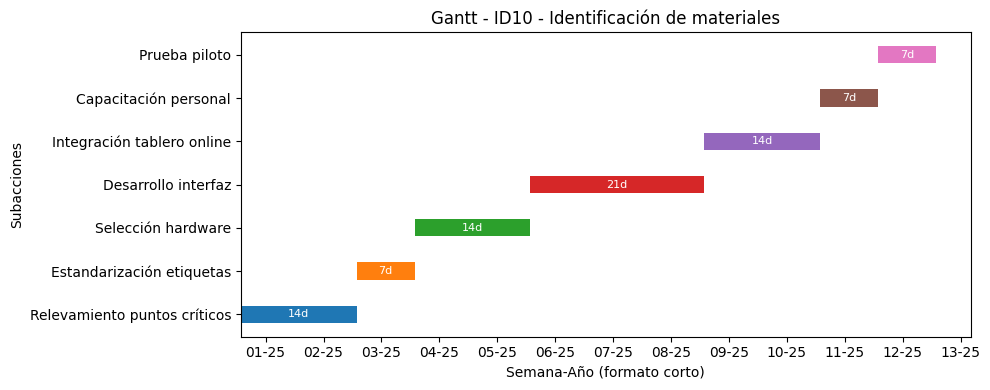

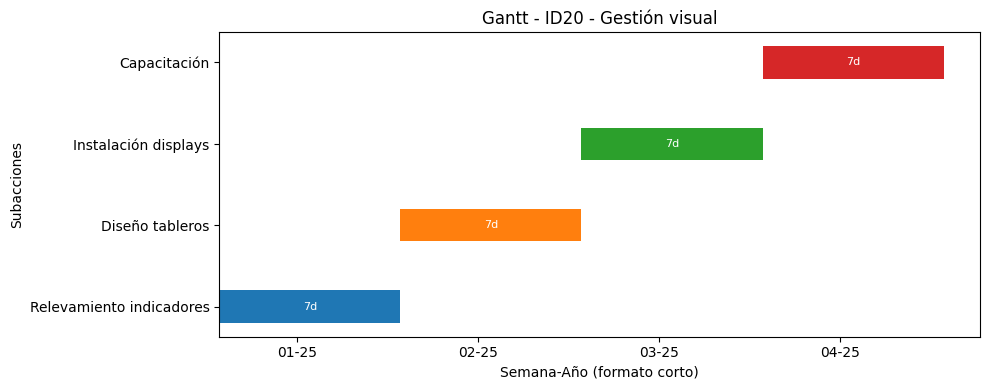

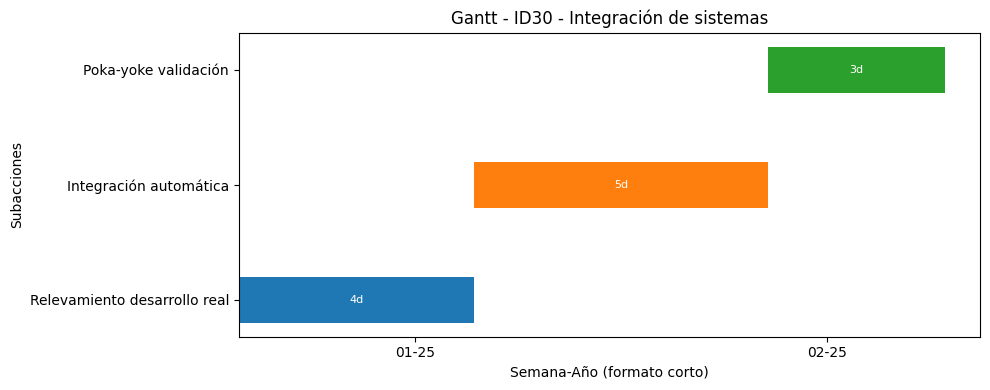

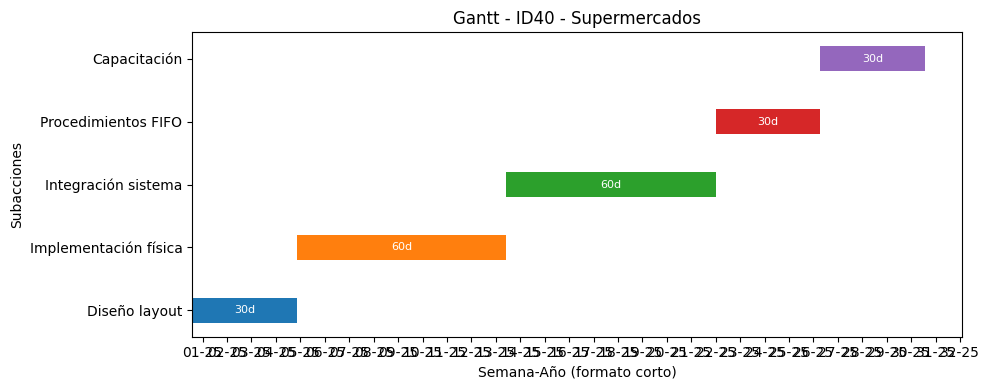

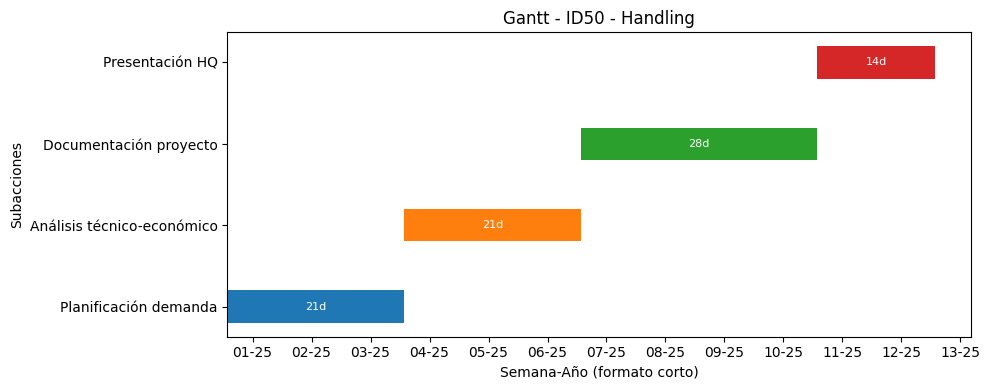

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import date2num, num2date
from datetime import datetime, timedelta
import matplotlib.ticker as ticker

# === Función para formatear eje semana-año (dos dígitos) ===
def format_week_year(x, pos=None):
    dt = num2date(x)
    week = dt.strftime("%U")   # Semana del año
    year = dt.strftime("%y")   # Año con dos dígitos
    return f"{week}-{year}"

# === Definir las tareas con tiempos estimados ===
tasks = [
    # ID10
    {"group": "ID10 - Identificación de materiales", "task": "Relevamiento puntos críticos", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Estandarización etiquetas", "duration": 7},
    {"group": "ID10 - Identificación de materiales", "task": "Selección hardware", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Desarrollo interfaz", "duration": 21},
    {"group": "ID10 - Identificación de materiales", "task": "Integración tablero online", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Capacitación personal", "duration": 7},
    {"group": "ID10 - Identificación de materiales", "task": "Prueba piloto", "duration": 7},

    # ID20
    {"group": "ID20 - Gestión visual", "task": "Relevamiento indicadores", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Diseño tableros", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Instalación displays", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Capacitación", "duration": 7},

    # ID30
    {"group": "ID30 - Integración de sistemas", "task": "Relevamiento desarrollo real", "duration": 4},
    {"group": "ID30 - Integración de sistemas", "task": "Integración automática", "duration": 5},
    {"group": "ID30 - Integración de sistemas", "task": "Poka-yoke validación", "duration": 3},

    # ID40
    {"group": "ID40 - Supermercados", "task": "Diseño layout", "duration": 30},
    {"group": "ID40 - Supermercados", "task": "Implementación física", "duration": 60},
    {"group": "ID40 - Supermercados", "task": "Integración sistema", "duration": 60},
    {"group": "ID40 - Supermercados", "task": "Procedimientos FIFO", "duration": 30},
    {"group": "ID40 - Supermercados", "task": "Capacitación", "duration": 30},

    # ID50
    {"group": "ID50 - Handling", "task": "Planificación demanda", "duration": 21},
    {"group": "ID50 - Handling", "task": "Análisis técnico-económico", "duration": 21},
    {"group": "ID50 - Handling", "task": "Documentación proyecto", "duration": 28},
    {"group": "ID50 - Handling", "task": "Presentación HQ", "duration": 14},
]

# === Crear DataFrame ===
df = pd.DataFrame(tasks)
start_date = datetime(2025, 1, 6)  # lunes semana 1 2025
df["start"] = None
df["end"] = None

group_offsets = {}
for i, row in df.iterrows():
    group = row["group"]
    if group not in group_offsets:
        group_offsets[group] = start_date
    df.at[i, "start"] = group_offsets[group]
    df.at[i, "end"] = group_offsets[group] + timedelta(days=row["duration"])
    group_offsets[group] = df.at[i, "end"]

# === Graficar por grupo ===
for group in df["group"].unique():
    fig, ax = plt.subplots(figsize=(10, 4))
    gdf = df[df["group"] == group]
    for i, row in enumerate(gdf.itertuples()):
        ax.barh(row.task, (row.end - row.start).days, left=date2num(row.start), height=0.4)
        ax.text(date2num(row.start) + (row.end - row.start).days/2, i,
                f"{(row.end - row.start).days}d", va='center', ha='center', color='white', fontsize=8)

    ax.set_title(f"Gantt - {group}")
    ax.set_ylabel("Subacciones")
    ax.set_xlabel("Semana-Año (formato corto)")

    # formato semana-año (dos dígitos)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_week_year))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(7))  # tick cada semana

    plt.tight_layout()
    plt.show()


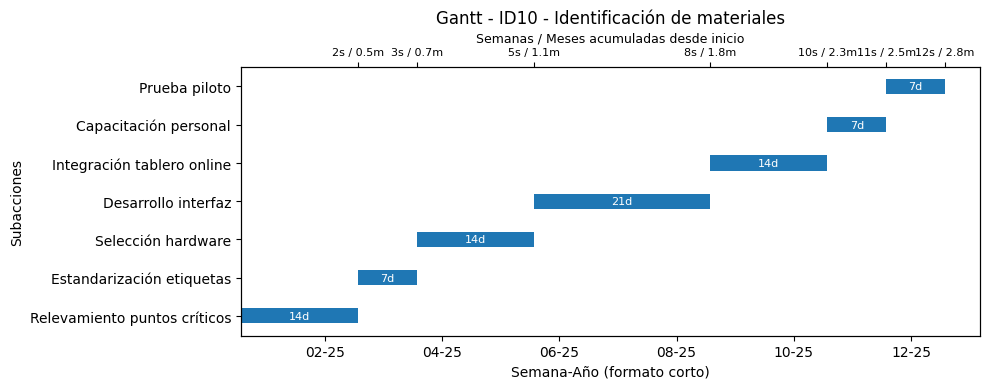

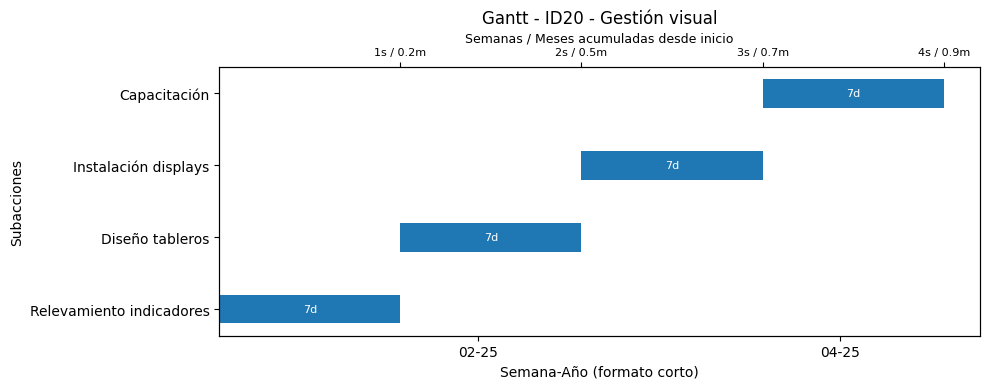

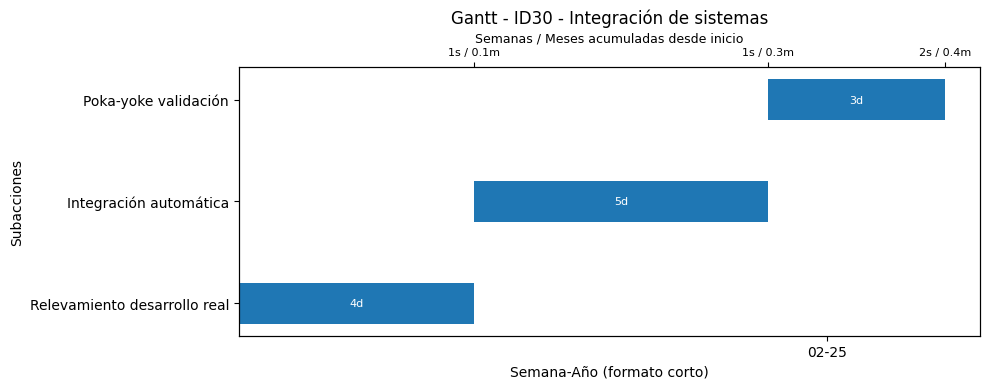

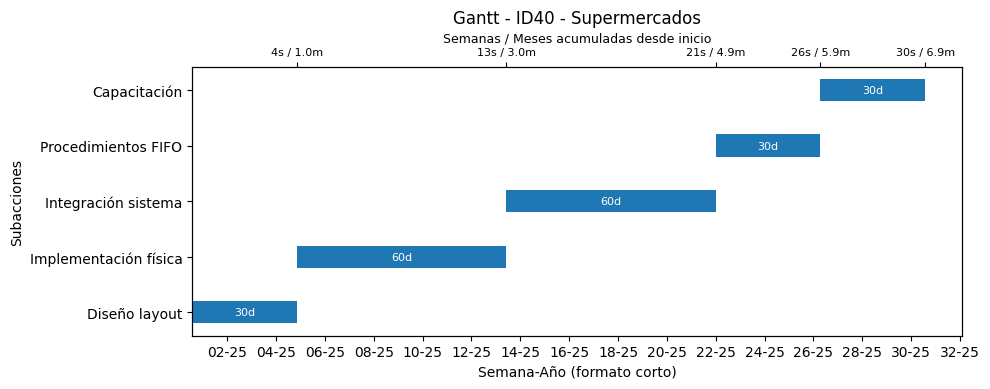

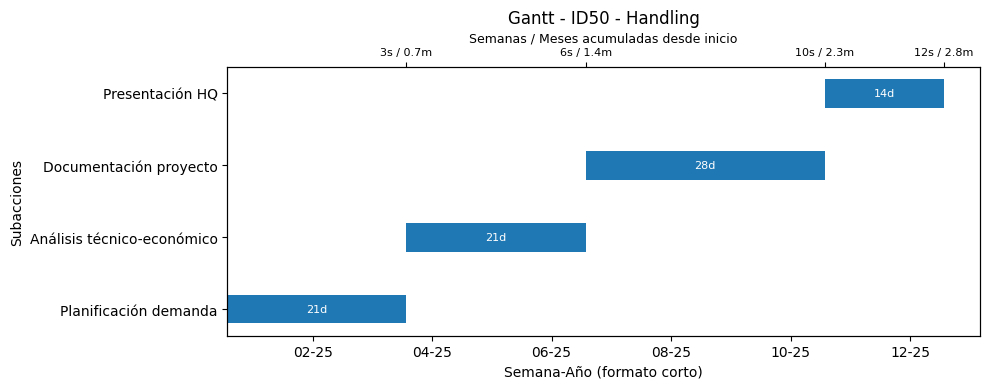

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import date2num, num2date
from datetime import datetime, timedelta
import matplotlib.ticker as ticker

# === Función para formatear eje semana-año (dos dígitos) ===
def format_week_year(x, pos=None):
    dt = num2date(x)
    week = dt.strftime("%U")   # Semana del año
    year = dt.strftime("%y")   # Año con dos dígitos
    return f"{week}-{year}"

# === Definir las tareas con tiempos estimados ===
tasks = [
    # ID10
    {"group": "ID10 - Identificación de materiales", "task": "Relevamiento puntos críticos", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Estandarización etiquetas", "duration": 7},
    {"group": "ID10 - Identificación de materiales", "task": "Selección hardware", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Desarrollo interfaz", "duration": 21},
    {"group": "ID10 - Identificación de materiales", "task": "Integración tablero online", "duration": 14},
    {"group": "ID10 - Identificación de materiales", "task": "Capacitación personal", "duration": 7},
    {"group": "ID10 - Identificación de materiales", "task": "Prueba piloto", "duration": 7},

    # ID20
    {"group": "ID20 - Gestión visual", "task": "Relevamiento indicadores", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Diseño tableros", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Instalación displays", "duration": 7},
    {"group": "ID20 - Gestión visual", "task": "Capacitación", "duration": 7},

    # ID30
    {"group": "ID30 - Integración de sistemas", "task": "Relevamiento desarrollo real", "duration": 4},
    {"group": "ID30 - Integración de sistemas", "task": "Integración automática", "duration": 5},
    {"group": "ID30 - Integración de sistemas", "task": "Poka-yoke validación", "duration": 3},

    # ID40
    {"group": "ID40 - Supermercados", "task": "Diseño layout", "duration": 30},
    {"group": "ID40 - Supermercados", "task": "Implementación física", "duration": 60},
    {"group": "ID40 - Supermercados", "task": "Integración sistema", "duration": 60},
    {"group": "ID40 - Supermercados", "task": "Procedimientos FIFO", "duration": 30},
    {"group": "ID40 - Supermercados", "task": "Capacitación", "duration": 30},

    # ID50
    {"group": "ID50 - Handling", "task": "Planificación demanda", "duration": 21},
    {"group": "ID50 - Handling", "task": "Análisis técnico-económico", "duration": 21},
    {"group": "ID50 - Handling", "task": "Documentación proyecto", "duration": 28},
    {"group": "ID50 - Handling", "task": "Presentación HQ", "duration": 14},
]

# === Crear DataFrame ===
df = pd.DataFrame(tasks)
start_date = datetime(2025, 1, 6)  # lunes semana 1 2025
df["start"] = None
df["end"] = None

group_offsets = {}
for i, row in df.iterrows():
    group = row["group"]
    if group not in group_offsets:
        group_offsets[group] = start_date
    df.at[i, "start"] = group_offsets[group]
    df.at[i, "end"] = group_offsets[group] + timedelta(days=row["duration"])
    group_offsets[group] = df.at[i, "end"]

# === Graficar por grupo ===
for group in df["group"].unique():
    fig, ax = plt.subplots(figsize=(10, 4))
    gdf = df[df["group"] == group]
    
    # Dibujar barras
    for i, row in enumerate(gdf.itertuples()):
        ax.barh(row.task, (row.end - row.start).days, left=date2num(row.start), height=0.4, color="#1f77b4")
        ax.text(date2num(row.start) + (row.end - row.start).days / 2, i,
                f"{(row.end - row.start).days}d", va='center', ha='center', color='white', fontsize=8)

    # Eje inferior
    ax.set_title(f"Gantt - {group}")
    ax.set_ylabel("Subacciones")
    ax.set_xlabel("Semana-Año (formato corto)")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_week_year))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(14))  # tick cada 2 semanas para mejor legibilidad

    # === Eje superior: semanas / meses acumuladas ===
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())

    # Calcular acumulado total
    min_start = gdf["start"].min()
    total_days = (gdf["end"].max() - min_start).days
    total_weeks = total_days / 7
    total_months = total_days / 30.44

    # Posiciones de tick = fin de cada subacción
    tick_positions = [date2num(end) for end in gdf["end"]]
    labels = []
    for end_date in gdf["end"]:
        weeks_elapsed = (end_date - min_start).days / 7
        months_elapsed = (end_date - min_start).days / 30.44
        labels.append(f"{weeks_elapsed:.0f}s / {months_elapsed:.1f}m")

    # Asegurar que el último label sea el total
    if tick_positions[-1] < date2num(gdf["end"].max()):
        tick_positions.append(date2num(gdf["end"].max()))
        labels.append(f"{total_weeks:.0f}s / {total_months:.1f}m")
    else:
        labels[-1] = f"{total_weeks:.0f}s / {total_months:.1f}m"

    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(labels, fontsize=8, rotation=0)
    ax2.set_xlabel("Semanas / Meses acumuladas desde inicio", fontsize=9)

    plt.tight_layout()
    plt.show()
